In [2]:
import numpy as np
import matplotlib.pyplot as plt

def read_data(path, skip):
    return np.genfromtxt(path, skip_header=skip)

def autocorrelation(data):
    n_measurements = len(data[:,0])
    corr_t = np.zeros(n_measurements)
    avgmodsq = np.sum(data*data)/n_measurements
    for i in range(n_measurements):
        back_index = n_measurements - i
        if ((i%1000)==0):
            print(i, back_index)
        dot_prods = data[i:, :] * data[:back_index, :] / avgmodsq
        avg_dot_prods = np.mean(np.sum(dot_prods, axis=1))
        corr_t[i] = corr_t[i] + avg_dot_prods 
    return corr_t

path = './easy_axis_correlation/sigma10/sim_1/data_sus_frozen_10.0'
nskip = 100000
nsims = 8

corr_t = np.zeros(len(read_data(path, nskip)[1::10]))

for i in range(nsims):
    path = f'./easy_axis_correlation/sigma10/sim_{i+1}/data_sus_frozen_10.0'

    temp_array = read_data(path, nskip)
    magnetization_t = temp_array[1::10].copy()
    
    #magnetization_t = alt_read_data(alt_path, 4950000)
    corr_t += autocorrelation(magnetization_t)

corr_t = corr_t/nsims



/home/coldstream/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


0 90000
1000 89000
2000 88000
3000 87000
4000 86000
5000 85000
6000 84000
7000 83000
8000 82000
9000 81000
10000 80000
11000 79000
12000 78000
13000 77000
14000 76000
15000 75000
16000 74000
17000 73000
18000 72000
19000 71000
20000 70000
21000 69000
22000 68000
23000 67000
24000 66000
25000 65000
26000 64000
27000 63000
28000 62000
29000 61000
30000 60000
31000 59000
32000 58000
33000 57000
34000 56000
35000 55000
36000 54000
37000 53000
38000 52000
39000 51000
40000 50000
41000 49000
42000 48000
43000 47000
44000 46000
45000 45000
46000 44000
47000 43000
48000 42000
49000 41000
50000 40000
51000 39000
52000 38000
53000 37000
54000 36000
55000 35000
56000 34000
57000 33000
58000 32000
59000 31000
60000 30000
61000 29000
62000 28000
63000 27000
64000 26000
65000 25000
66000 24000
67000 23000
68000 22000
69000 21000
70000 20000
71000 19000
72000 18000
73000 17000
74000 16000
75000 15000
76000 14000
77000 13000
78000 12000
79000 11000
80000 10000
81000 9000
82000 8000
83000 7000
84000 60

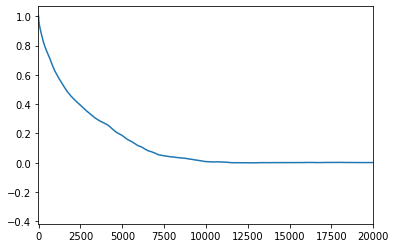

In [19]:
t = np.arange(len(corr_t))
plt.xlim([-10,20000])
plt.plot(t, corr_t)

In [1]:
### Do the fourier transform
### frequencies to sample, distributed evenly in logspace
omegas = 10**(np.linspace(-5,2,num=1000))
re_chi_omega = np.zeros(len(omegas))
im_chi_omega = np.zeros(len(omegas))

for i, omega in enumerate(omegas):
    for t, c in enumerate(corr_t):
        re_chi_omega[i] += c * np.cos(omega*t*0.001*200)
        im_chi_omega[i] += c * np.sin(omega*t*0.001*200)

### Normalise the output
norm_const = re_chi_omega[0]
re_chi_omega = re_chi_omega/norm_const
im_chi_omega = im_chi_omega/norm_const

plt.xscale('log')
plt.plot(omegas, re_chi_omega)
plt.plot(omegas, im_chi_omega)

NameError: name 'np' is not defined